# Gain Scheduling with Feedback Linearization and Discrete Transfer Functions

This notebook implements Gain Scheduling for the 1/4 drone utilizing the exact MATLAB State-Space architecture, combined with **Feedback Linearization**.
1. We define a virtual control input $v = u^2$ to completely remove the singularity at $B=0$ near $0^\circ$ and $180^\circ$.
2. The Jacobians $(A, B_v)$ are globally controllable!
3. We allocate Servosystem poles with an Integrator and a Luenberger Observer.
4. We extract and discretize the two Transfer Functions $G_{cr}(z)$ and $G_{cy}(z)$.
5. We create interpolators directly on the Transfer Function polynomial coefficients.
6. The simulation uses the discrete difference equation to compute $\Delta v$, recovers the actual control $u = \sqrt{v}$, and uses `solve_ivp` for the continuous plant.

In [1]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.integrate import solve_ivp
from scipy.interpolate import interp1d
import control as ct
import warnings
warnings.filterwarnings('ignore')

# Identified parameters from phys_14_drone.ipynb
c1 = -8.29151533
c2 = 0.00418887
c3 = -1.43673669

# Bounds
u_min, u_max = -100.0, 100.0
Ts = 0.05  # Sampling time


## 1. Linearization (with $v=u^2$), Control Design & Discretization
For each angle, we calculate $v_{eq}$ and the controller matrices, extracting the discrete TF coefficients.

In [2]:
angles_deg = np.array([0, 30, 60, 90, 120, 150, 180], dtype=float)
angles_rad = np.deg2rad(angles_deg)

v_eq_list = []
br_list = []
by_list = []
a_list = []

# Desired poles
P = [-3, -4, -5]       # Servosystem poles (dominant at -3)
Pe = [-15, -20]        # Observer poles

def pad_coeffs(c, target_len=4):
    if len(c) < target_len:
        return np.concatenate([np.zeros(target_len - len(c)), c])
    return np.array(c)

print("Controller Design Summary:")
print("-" * 50)
for th in angles_rad:
    sin_th = np.clip(np.sin(th), 0, None) 
    
    # Equilibrium virtual control
    v_eq = (-c1 * sin_th) / c2
    v_eq_list.append(v_eq)
    
    A = np.array([[0.0, 1.0],
                  [c1 * np.cos(th), c3]])
    
    # B matrix is strictly constant and non-zero everywhere!
    B_v = np.array([[0.0],
                    [c2]])
    C = np.array([[1.0, 0.0]])
        
    # 1. Controllability & Observability Checks
    M_c = np.block([[A, B_v], [-C, 0.0]])
    rank_Mc = np.linalg.matrix_rank(M_c)
    W_o = ct.obsv(A, C)
    rank_Wo = np.linalg.matrix_rank(W_o)
    
    # 2. Servosystem and Observer Pole Allocation
    Aa = np.block([[A, np.zeros((2, 1))],
                   [-C, 0.0]])
    Ba = np.block([[B_v],
                   [0.0]])
    
    Kaux = ct.acker(Aa, Ba, P)
    K = Kaux.flatten()[:2].reshape(1, 2)
    Ki = -Kaux.flatten()[2]
    
    Ke = ct.acker(A.T, C.T, Pe).flatten().reshape(2, 1)
    
    # 3. Regulator-Observer Assembly
    At = np.block([[A - Ke@C - B_v@K, B_v * Ki], 
                   [np.zeros((1, 2)), 0.0]])
    Bt = np.block([[np.zeros((2, 1)), Ke], 
                   [1.0, -1.0]])
    Ct = np.block([[-K, Ki]])
    Dt = np.zeros((1, 2))
    
    # 4. Extract Transfer Functions and Discretize
    Gc = ct.ss(At, Bt, Ct, Dt)
    Gc_d = Gc.sample(Ts, method='tustin')
    Gc_tf = ct.ss2tf(Gc_d)
    
    num_r = pad_coeffs(Gc_tf.num[0][0])
    num_y = pad_coeffs(Gc_tf.num[0][1])
    den = pad_coeffs(Gc_tf.den[0][0])
    
    a0 = den[0]
    num_r = num_r / a0
    num_y = num_y / a0
    den = den / a0
    
    br_list.append(num_r)
    by_list.append(num_y)
    a_list.append(den)
    
    print(f"Angle {np.rad2deg(th):>3.0f} deg | Rank Mc={rank_Mc}, Rank Wo={rank_Wo} | TFs extracted.")

br_array = np.vstack(br_list)
by_array = np.vstack(by_list)
a_array = np.vstack(a_list)


Controller Design Summary:
--------------------------------------------------
Angle   0 deg | Rank Mc=3, Rank Wo=2 | TFs extracted.
Angle  30 deg | Rank Mc=3, Rank Wo=2 | TFs extracted.
Angle  60 deg | Rank Mc=3, Rank Wo=2 | TFs extracted.
Angle  90 deg | Rank Mc=3, Rank Wo=2 | TFs extracted.
Angle 120 deg | Rank Mc=3, Rank Wo=2 | TFs extracted.
Angle 150 deg | Rank Mc=3, Rank Wo=2 | TFs extracted.
Angle 180 deg | Rank Mc=3, Rank Wo=2 | TFs extracted.


## 2. Gain Scheduling Interpolators

In [3]:
interp_veq = interp1d(angles_deg, v_eq_list, kind='cubic', fill_value='extrapolate')
interp_br = interp1d(angles_deg, br_array, axis=0, kind='linear', fill_value='extrapolate')
interp_by = interp1d(angles_deg, by_array, axis=0, kind='linear', fill_value='extrapolate')
interp_a  = interp1d(angles_deg, a_array, axis=0, kind='linear', fill_value='extrapolate')

print("Interpolators created.")


Interpolators created.


## 3. Visualization of Scheduled Discrete TF Coefficients

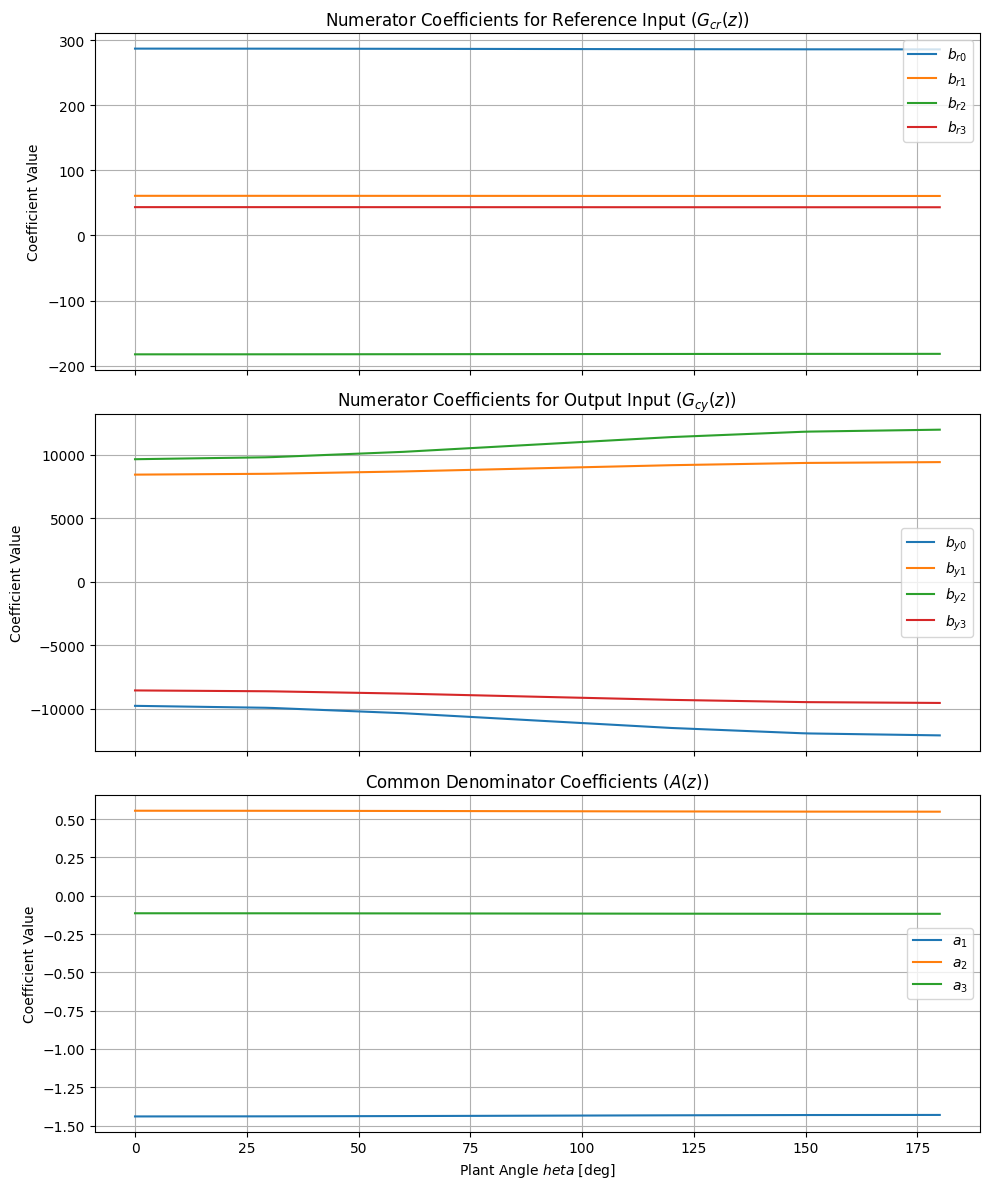

In [4]:
th_plot = np.linspace(0, 180, 100)

br_plot = interp_br(th_plot)
by_plot = interp_by(th_plot)
a_plot = interp_a(th_plot)

fig, axs = plt.subplots(3, 1, figsize=(10, 12), sharex=True)

for i in range(4):
    axs[0].plot(th_plot, br_plot[:, i], label=f'$b_{{r{i}}}$')
axs[0].set_title('Numerator Coefficients for Reference Input ($G_{cr}(z)$)')
axs[0].set_ylabel('Coefficient Value')
axs[0].legend()
axs[0].grid(True)

for i in range(4):
    axs[1].plot(th_plot, by_plot[:, i], label=f'$b_{{y{i}}}$')
axs[1].set_title('Numerator Coefficients for Output Input ($G_{cy}(z)$)')
axs[1].set_ylabel('Coefficient Value')
axs[1].legend()
axs[1].grid(True)

for i in range(1, 4):
    axs[2].plot(th_plot, a_plot[:, i], label=f'$a_{i}$')
axs[2].set_title('Common Denominator Coefficients ($A(z)$)')
axs[2].set_xlabel('Plant Angle $\theta$ [deg]')
axs[2].set_ylabel('Coefficient Value')
axs[2].legend()
axs[2].grid(True)

plt.tight_layout()
plt.show()


## 4. Nonlinear Simulation
We simulate the staircase reference using the difference equation computing virtual control $\Delta v[k]$.

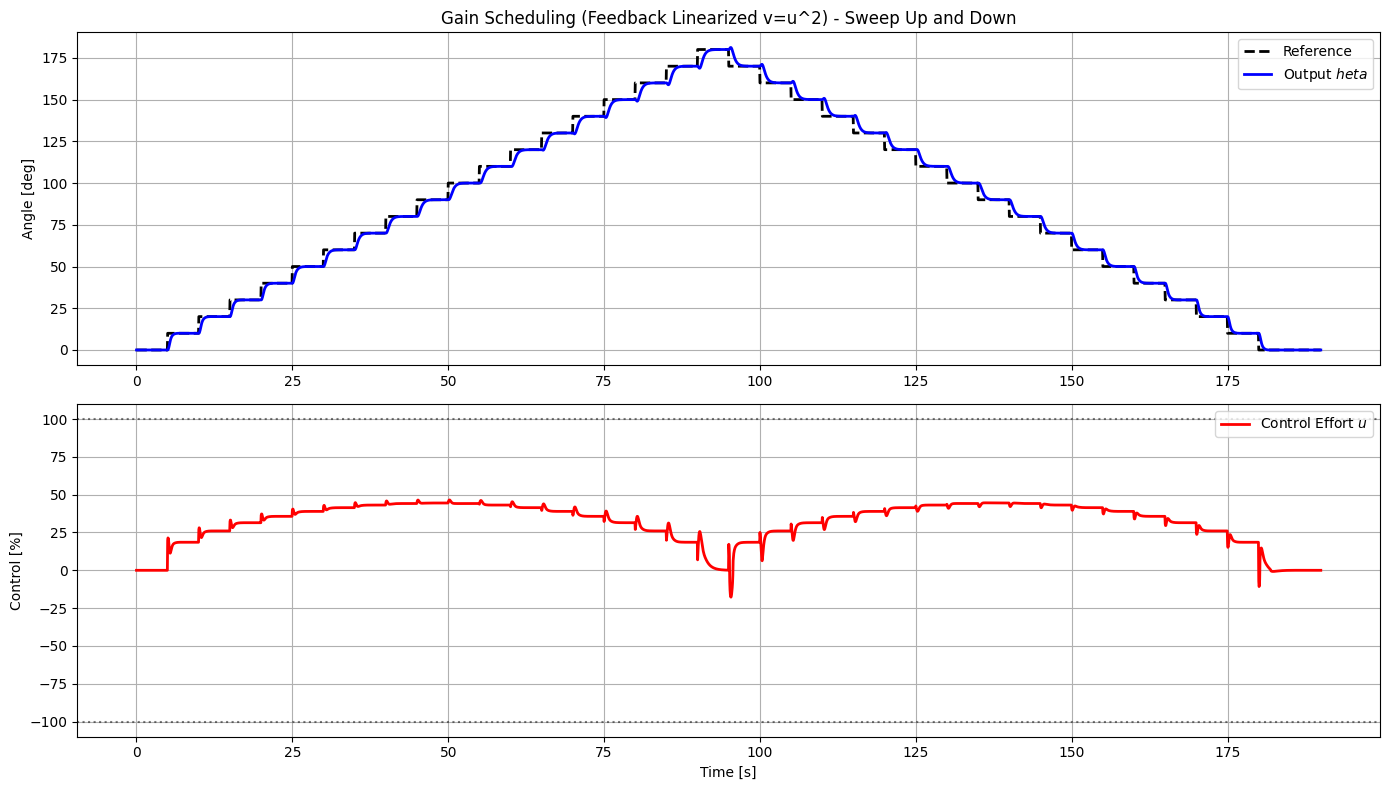

In [5]:
# Simulation Settings
T_sim = 190.0
t_steps = np.arange(0, T_sim, Ts)

def get_ref(t):
    step = int(t // 5) # 5 seconds per step
    if step <= 18:
        # Going up: 0 to 180 in steps of 10
        return step * 10
    else:
        # Going down: 180 back to 0 in steps of 10
        return max(180 - (step - 18) * 10, 0)

def drone_dynamics(t, x, u_val):
    th, th_dot = x
    th_ddot = c1 * np.sin(th) + c2 * u_val * np.abs(u_val) + c3 * th_dot
    return [th_dot, th_ddot]

y_hist = []
r_hist = []
u_hist = []

x_plant = np.array([0.0, 0.0])

r_buf = np.zeros(4)
y_buf = np.zeros(4)
dv_buf = np.zeros(4)

for t in t_steps:
    r_deg = get_ref(t)
    r_rad = np.deg2rad(r_deg)
    y_rad = x_plant[0]
    y_deg = np.rad2deg(y_rad)
    
    r_buf[1:] = r_buf[:-1]
    y_buf[1:] = y_buf[:-1]
    dv_buf[1:] = dv_buf[:-1]
    
    r_buf[0] = r_rad
    y_buf[0] = y_rad
    
    # Gain Scheduling
    sched_angle = np.clip(y_deg, 0, 180) 
    sched_ref = np.clip(r_deg, 0, 180)
    
    v_eq = interp_veq(sched_ref) 
    
    br = interp_br(sched_angle)
    by = interp_by(sched_angle)
    a  = interp_a(sched_angle)
    
    # Difference Equation for Delta v[k]
    dv_k = np.dot(br, r_buf) + np.dot(by, y_buf) - np.dot(a[1:], dv_buf[1:])
    dv_buf[0] = dv_k
    
    # Total virtual control effort
    v_k = v_eq + dv_k
    
    # Map back to actual physical input: u = sqrt(v)
    # Ensure v_k is non-negative before sqrt
    u_k = np.sign(v_k) * np.sqrt(np.abs(v_k))
    u_k = np.clip(u_k, u_min, u_max)
    
    y_hist.append(y_deg)
    r_hist.append(r_deg)
    u_hist.append(u_k)
    
    sol = solve_ivp(drone_dynamics, [t, t + Ts], x_plant, args=(u_k,), method='RK45')
    x_plant = sol.y[:, -1]

# Plotting
plt.figure(figsize=(14, 8))

plt.subplot(2, 1, 1)
plt.plot(t_steps, r_hist, 'k--', label='Reference', lw=2)
plt.plot(t_steps, y_hist, 'b-', label='Output $\theta$', lw=2)
plt.ylabel('Angle [deg]')
plt.title('Gain Scheduling (Feedback Linearized v=u^2) - Sweep Up and Down')
plt.grid(True)
plt.legend()

plt.subplot(2, 1, 2)
plt.plot(t_steps, u_hist, 'r-', label='Control Effort $u$', lw=2)
plt.axhline(u_max, color='k', ls=':', alpha=0.5)
plt.axhline(u_min, color='k', ls=':', alpha=0.5)
plt.ylabel('Control [%]')
plt.xlabel('Time [s]')
plt.grid(True)
plt.legend()

plt.tight_layout()
plt.show()
